# 🐢 EPOCH Pilot Task 
> 주제: 카드 소비 데이터에 기반한 고객 유형별 이탈 요인 분석

### TASK 1. 데이터 출처 설명 / 불러오기

* 데이터: Kaggle - Credit Card customers
(https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

* 개요: This dataset consists of 10,000 customers mentioning their age, salary, marital_status, credit card limit, credit card category, etc. There are nearly 18 features. We have only 16.07% of customers who have churned.

선정 이유: 카드 결제 데이터는 한 사람의 일상에 가장 가까운 데이터라고 생각합니다. 이전부터 그 점이 상당히 매력적으로 느껴졌고, 언젠가 꼭 한번은 분석해보고 싶은 데이터였습니다.

카드 이탈 분석은 사실 상당히 보편적인 주제이긴 하나, 그만큼 카드사 입장에서 가장 중요한 과제 중 하나이기도 합니다. (많이들 하는 이유가 있는..) 그리고 보편적이기에 수많은 선행 분석 사례를 참고할 수 있다는 점에서 해당 주제를 선택했습니다 ^_^

> features (영문)
* CLIENTNUM: Client number. Unique identifier for the customer holding the account

* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then 1 else 0

* Customer_Age: Demographic variable - Customer's Age in Years

* Gender: Demographic variable - M=Male, F=Female

* Dependent_count: Demographic variable - Number of dependents

* Education_Level: Demographic variable - Educational Qualification of the account holder (example: high school, college graduate, etc.)

* Matiral_Status: Demographic variable - Married, Single, Divorced, Unknown

* Income_Category: Demographic variable - Annual Income Category of the account holder (< $40K, $40K - 60K, $60K - $80K, $80K-$120K, > $120K, Unknown)

* Card_Category: Product Variable - Type of Card (Blue, Silver, Gold, Platinum)

* Months_on_book: Period of relationship with bank

* Total_Relationship_Count: Total no. of products held by the customer

* Months_Inactive_12_mon: No. of months inactive in the last 12 months

* Contacts_Count_12_mon: No. of Contacts in the last 12 months

* Credit_Limit: Credit Limit on the Credit Card

* Total_Revolving_Bal: Total Revolving Balance on the Credit Card

* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)

* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)

* Total_Trans_Amt: Total Transaction Amount (Last 12 months)

* Total_Trans_Ct: Total Transaction Count (Last 12 months)

* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)

* Avg_Utilization_Ratio: Average Card Utilization Ratio

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2


> features (한글)

✏️ **고객 식별 및 타겟 변수**
* CLIENTNUM: 고객 번호 (고유 식별자)

* Attrition_Flag: 이탈 여부 (해지하면 1, 유지 중이면 0)

***

✏️ **인구통계학적 변수**
* Customer_Age: 나이 (만 나이)

* Gender: 성별

* Dependent_count: 부양가족 수

* Education_Level: 학력 수준 (예: 고졸, 대졸, 대학원 등)

* Matiral_Status: 결혼 상태 (기혼, 미혼, 이혼, 미상)

* Income_Category: 연 소득 (소득 구간)

***

✏️ **카드/상품 관련 변수**

* Card_Category: 카드 등급 (Blue, Silver, Gold, Platinum)

* Months_on_book: 거래 유지 기간 (개월 단위)

* Total_Relationship_Count: 보유한 은행 상품의 총 개수

* Months_Inactive_12_mon: 최근 12개월 중 카드 사용이 없던 개월 수

* Contacts_Count_12_mon: 최근 12개월 고객센터 접촉 횟수

* Credit_Limit: 신용카드 한도 금액

* Total_Revolving_Bal: 총 리볼빙 잔액 (결제하지 않고 이월된 금액)

* Avg_Open_To_Buy: 최근 12개월 평균 사용 가능한 잔여 한도 (신용한도-사용금액)

* Total_Amt_Chng_Q4_Q1: 4분기 대비 1분기 거래 금액 변화율

* Total_Trans_Amt: 최근 12개월 총 거래 금액

* Total_Trans_Ct: 최근 12개월 총 거래 횟수

* Total_Ct_Chng_Q4_Q1: 4분기 대비 1분기 거래 횟수 변화율

* Avg_Utilization_Ratio: 평균 카드 사용률 (사용금액/신용한도)

***

✏️ **Naive Bayes 관련 변수**

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: 나이브 베이즈 모델이 예측한 이탈 확률값

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: 나이브 베이즈 모델이 예측한 유지 확률값


#### 데이터 불러오기

In [1]:
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


* 우선, 마지막 2개 특성의 이름이 너무 길어서 읽기 번거로운 데다가, 분석이 끝난 후 검증 단계에서만 활용할 컬럼이므로 삭제

In [5]:
df = df.iloc[:, :-2]

In [6]:
df.shape

(10127, 21)

* 총 10,127명의 고객에 대한 21개 특성을 나타낸 데이터 준비 완료

### TASK 2. 기초 통계 확인

#### 변수 확인

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

##### 수치형 변수

In [8]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


##### 범주형 변수

In [9]:
df.describe(include='object')

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
count,10127,10127,10127,10127,10127,10127
unique,2,2,7,4,6,4
top,Existing Customer,F,Graduate,Married,Less than $40K,Blue
freq,8500,5358,3128,4687,3561,9436


#### 결측치, 중복값 확인

In [10]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [11]:
df.duplicated().sum()

np.int64(0)

* 결측치, 중복 데이터 모두 없음을 확인

### TASK 3. 분석 목적/인사이트 설명

> **⭐️ 최종 목표**

: 사용자 유형별 주요 이탈 요인을 기반으로 차별화된 리텐션 전략을 제시한다. 
신규 고객 발생 시 해당 고객을 적절한 군집으로 분류하여 자동으로 맞춤형 전략을 제공할 수 있도록 한다.

1. 연령, 성별 등 인구통계학적 특성에 따른 카드 소비 패턴을 분석하고, 이를 기반으로 고객을 군집화한다.
2. 도출된 군집별로 카드/상품 관련 변수 중 이탈에 유의미하게 기여하는 요인을 도출한다.

 (추가로, 본 데이터에서 제시된 베이즈 모델의 이탈/유지 예측 확률과 분석 결과를 비교함으로써 분석 결과를 검증한다.)


### TASK 4. EDA

> 이탈률 확인

In [12]:
df['Attrition_Flag'].value_counts()


,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [13]:
churn_rate = (df['Attrition_Flag'] == 'Attrited Customer').mean()
print(churn_rate)

0.1606596227905599


* 이탈률은 약 16%인 것으로 확인
* 그렇다면 각 특성별로 어떤 집단에서 가장 이탈률이 높은지 확인해보자

> 범주형 변수 확인

/tmp/ipykernel_26207/2035559760.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(churn_rate.index.astype(str), rotation=45)
/tmp/ipykernel_26207/2035559760.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(churn_rate.index.astype(str), rotation=45)
/tmp/ipykernel_26207/2035559760.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(churn_rate.index.astype(str), rotation=45)
/tmp/ipykernel_26207/2035559760.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(churn_rate.index.astype(str), rotation=45)
/tmp/ipykernel_26207/2035559760.py:23: UserWarning: set_ticklabels() should 

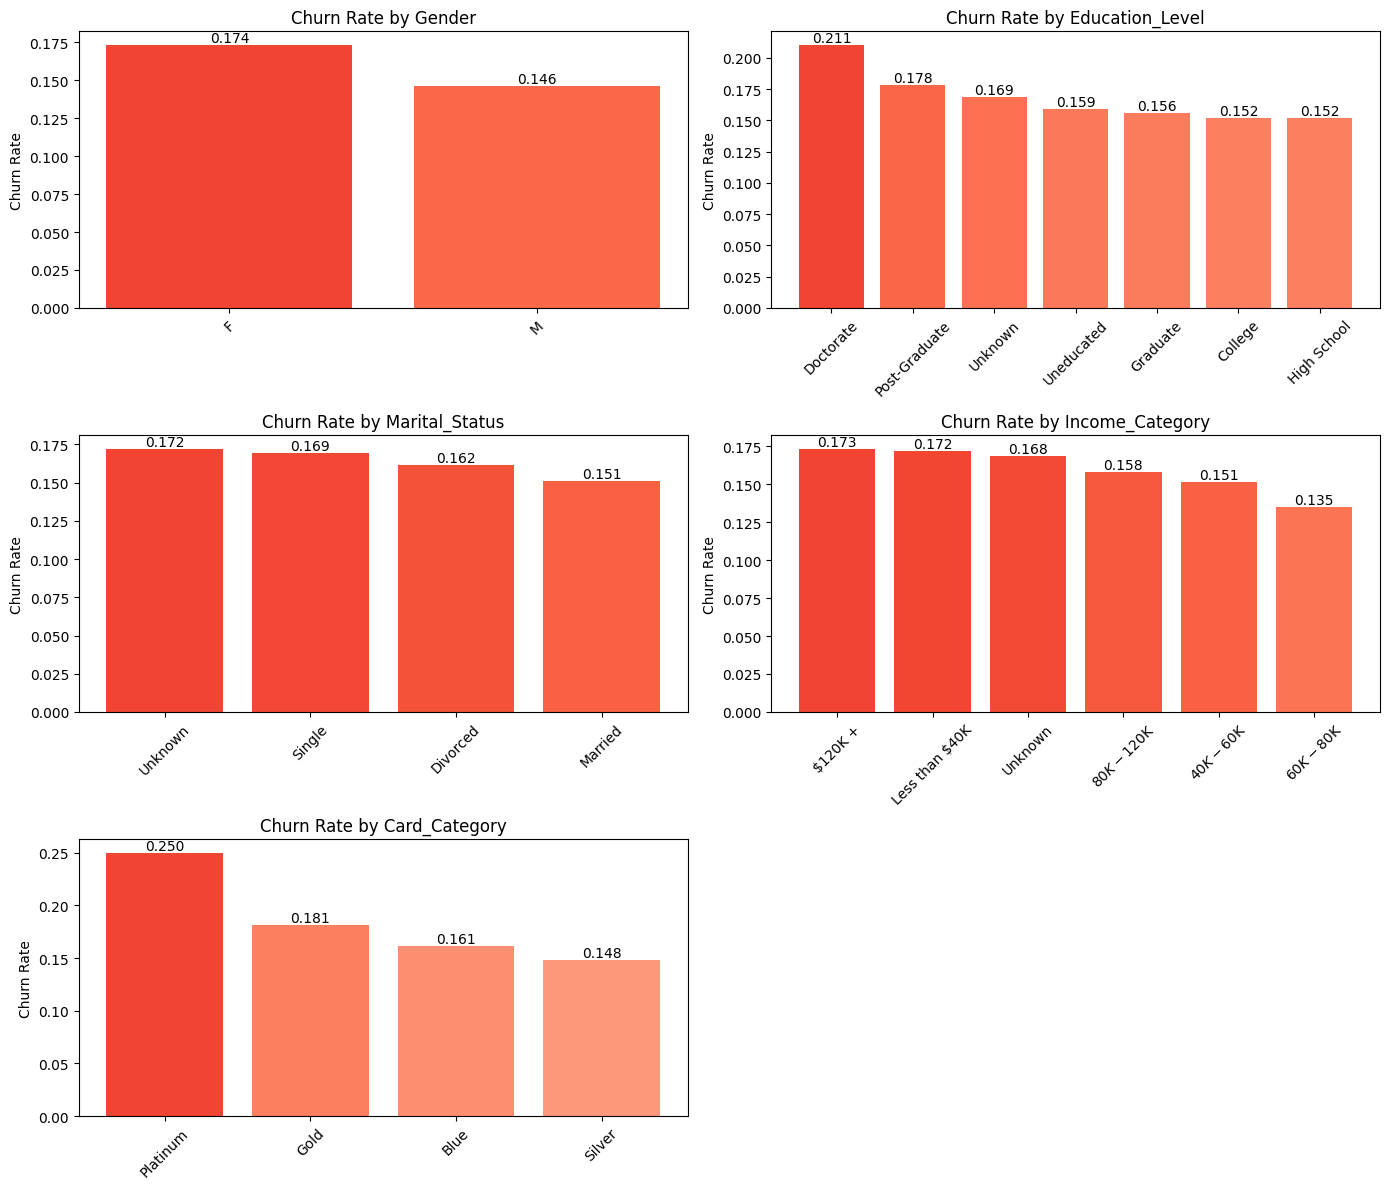

In [30]:
# churn 변수 생성
df['churn'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# 범주형 변수 선택 (Attrition_Flag 제외)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if 'Attrition_Flag' in categorical_cols:
    categorical_cols.remove('Attrition_Flag')

n = len(categorical_cols)
rows = math.ceil(n / 2)

fig, axes = plt.subplots(rows, 2, figsize=(14, 4*rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values, color=plt.cm.Reds(0.6 * churn_rate.values / churn_rate.values.max()))
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(churn_rate.index.astype(str), rotation=45)

    # 막대 위 숫자 표시
    for j, v in enumerate(churn_rate.values):
        ax.text(j, v, f'{v:.3f}', ha='center', va='bottom')

# 남는 subplot 제거
for k in range(i+1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

* 남성에 비해 **여성**에서 이탈률이 높게 나타났다.

* 학력 순서에 따라 이탈률이 나타나지는 않는다. 다만 가장 높은 학력인 **박사**에서 이탈률이 눈에 띄게 높게 나타난다. 다만 박사 집단의 표본 수가 다른 집단에 비해 적을 가능성이 높으므로 추후 자세히 확인.  

* **미상 > 미혼 > 이혼 > 미상** 순으로 나타난다. 차이게 크게 나타나지는 않으나, 대체로 가정이 없을 수록 이탈이 잦다. 안정적인 생활 패턴이 카드 유지에 영향을 줄 가능성? 

* **가장 수입이 높은/낮은 집단**에서 이탈률이 높다. 흥미로운 결과.

* **가장 높은 등급**의 카드 사용자에서 이탈률이 상당히 높다. 이들을 타겟팅하는 전략이 상당히 중요할 것으로 생각된다. 앞서 수입이 높은 사람이 높은 등급의 카드를 사용할 가능성이 높은데 실제로 그런지 추후 자세히 확인.

다른 집단에 비해 표본 수가 적은 경우가 있는지 파악해보자

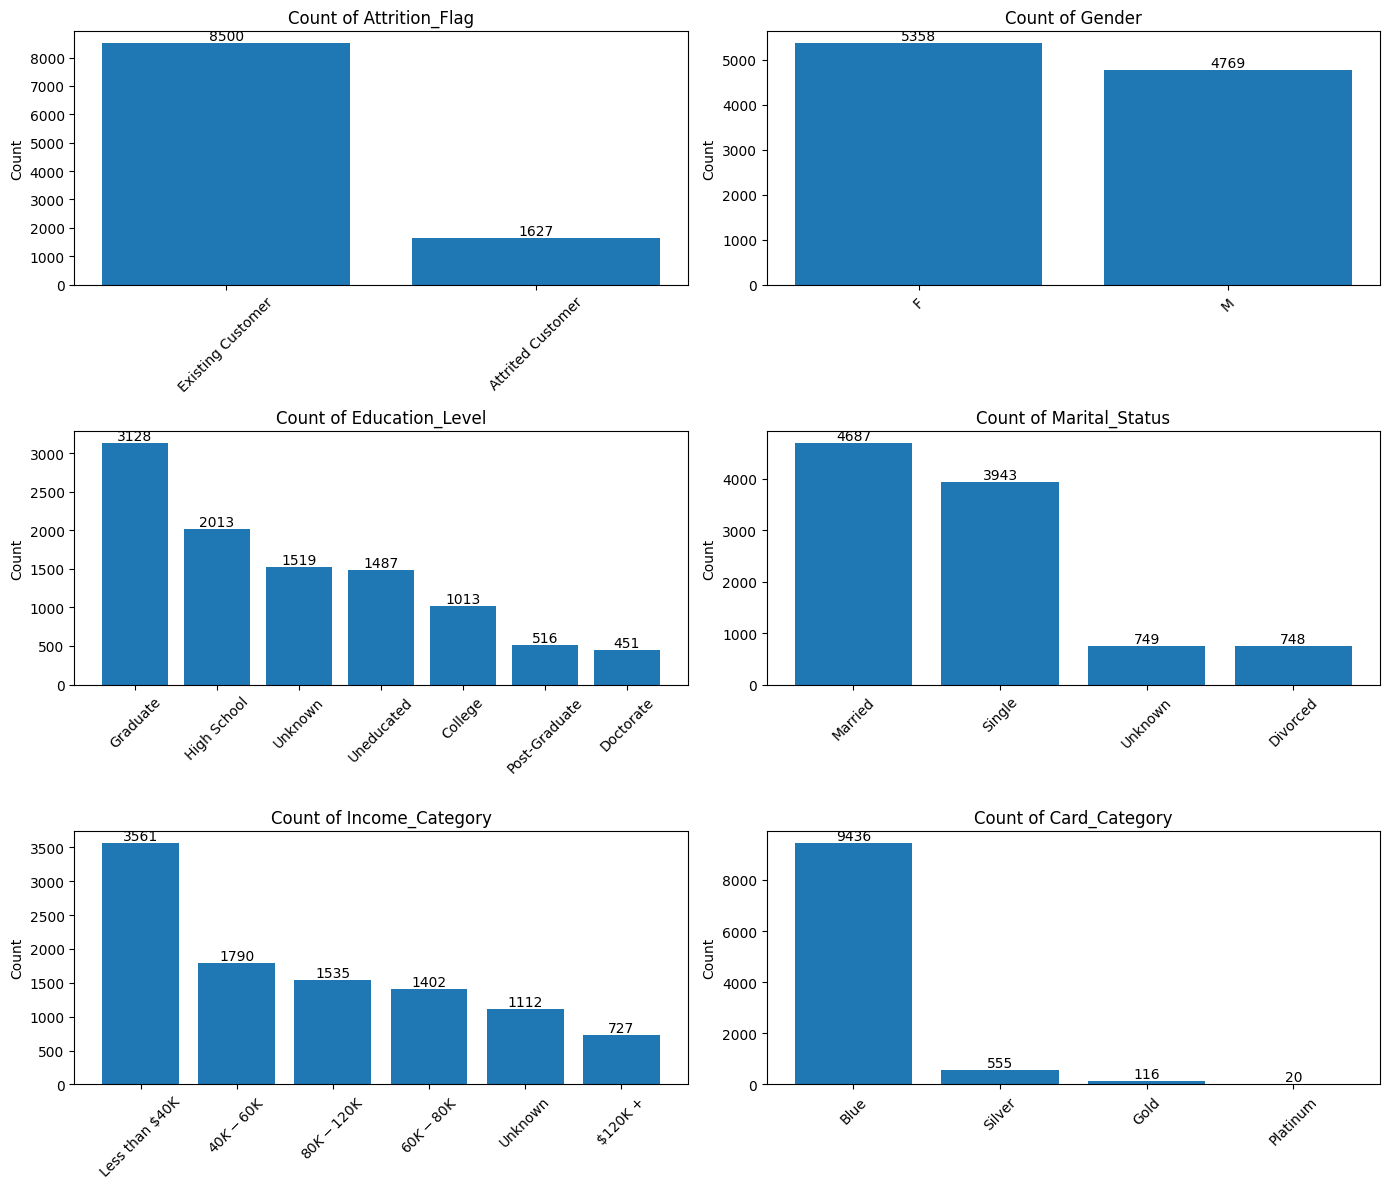

In [15]:
categorical_cols = df.select_dtypes(include='object').columns

n = len(categorical_cols)
rows = int(np.ceil(n / 2))

fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    
    bars = axes[i].bar(counts.index.astype(str), counts.values)
    
    axes[i].set_title(f'Count of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

    # 막대 위 숫자 표시
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* 카드 등급 중 Gold/Platinum 보유자 수가 너무 적다! 이탈률만 보고 판단하기엔 무리가 있다.

* 결혼 유무도 마찬가지로 집단 불균형이 심하게 나타난다.

#### 수치형 변수 확인

> 변수 구분 (이산형/연속형)

In [16]:
# ID, 타겟 제외
exclude_cols = ['CLIENTNUM', 'Attrition_Flag', 'churn']

# 수치형 전체
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# 이산형(카운트형) 후보: 고유값 개수가 적은 정수형
discrete_cols = [c for c in numeric_cols 
                 if (df[c].nunique() <= 10) and (pd.api.types.is_integer_dtype(df[c]))]

# 연속형: 나머지
continuous_cols = [c for c in numeric_cols if c not in discrete_cols]

print("Discrete:", discrete_cols)
print("Continuous:", continuous_cols)

Discrete: ['Dependent_count', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon']
Continuous: ['Customer_Age', 'Months_on_book', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


> 이산형 변수 확인

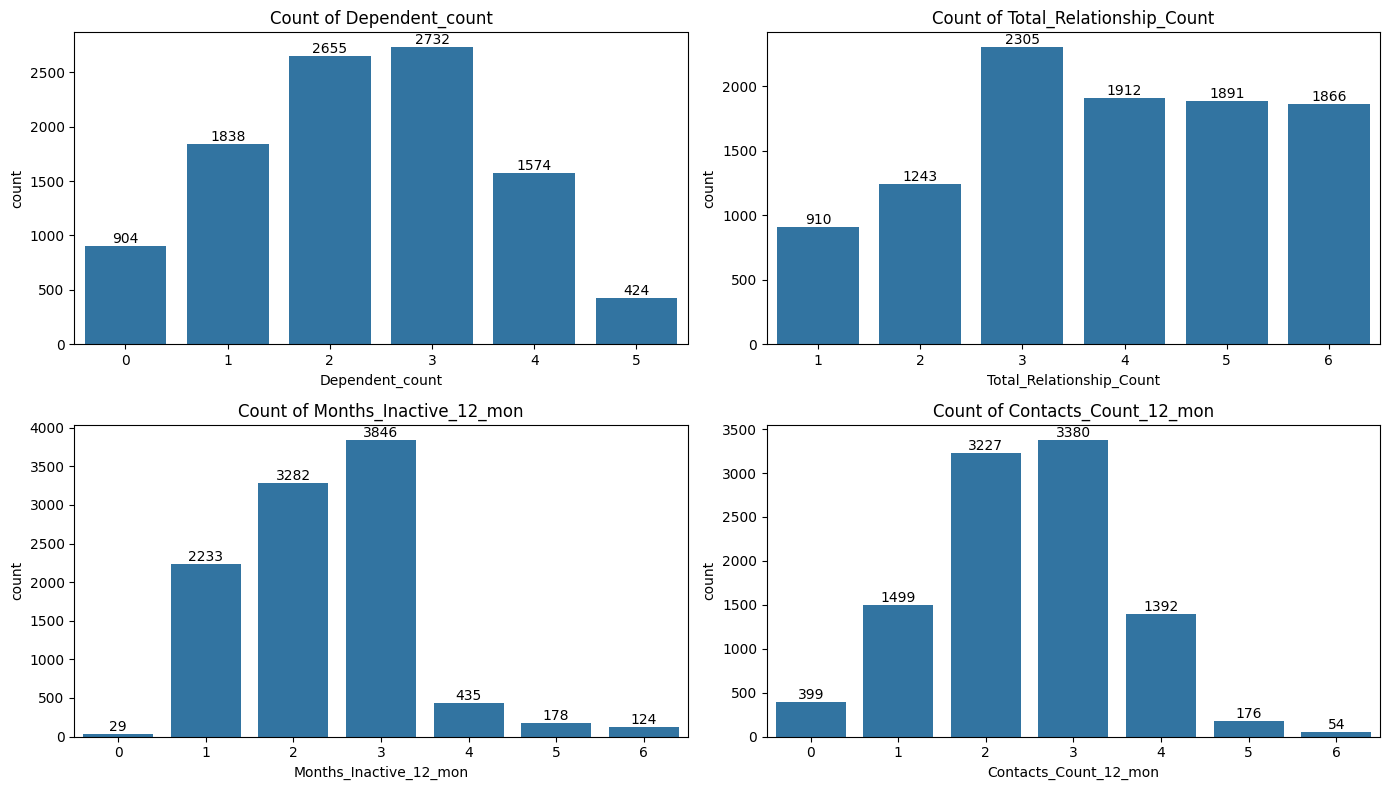

In [17]:
n = len(discrete_cols)
rows = int(np.ceil(n / 2))

fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 4))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=0)

    # 막대 위 숫자 표시
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(f'{int(height)}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom')

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* 위의 표본수에 유의하여 이탈률 확인

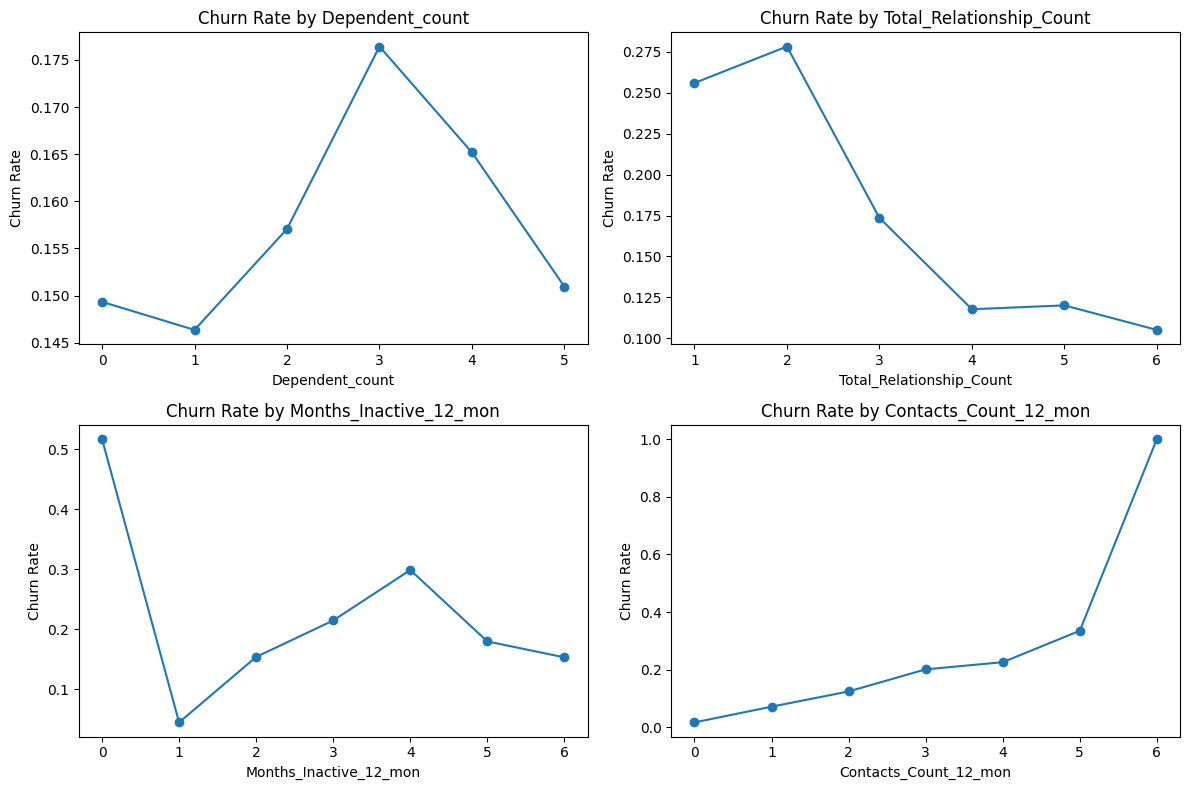

In [18]:
n = len(discrete_cols)
rows = int(np.ceil(n / 2))

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    churn_rate = df.groupby(col)['churn'].mean().sort_index()
    
    axes[i].plot(churn_rate.index, churn_rate.values, marker='o')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate')

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* 부양가족 수에 따라 약간의 일탈률 증가 경향이 있으나, 다른 변수들에 비해 약한 패턴으로 보여짐. y축 범위를 보면 차이가 적다.

* 보유한 상품의 수가 늘어날 수록 일탈률이 낮다!!

* 비활성 기간이 길 수록 일탈률 높게 나타난다. (0개월의 경우 표본이 너무 적어 결과 무의미)

* 고객센터 접촉 많이 할 수록 이탈률이 증가한다. 카드 해지 전의 시그널로 볼 수 있을 듯 하다.

> 수치형 변수 확인

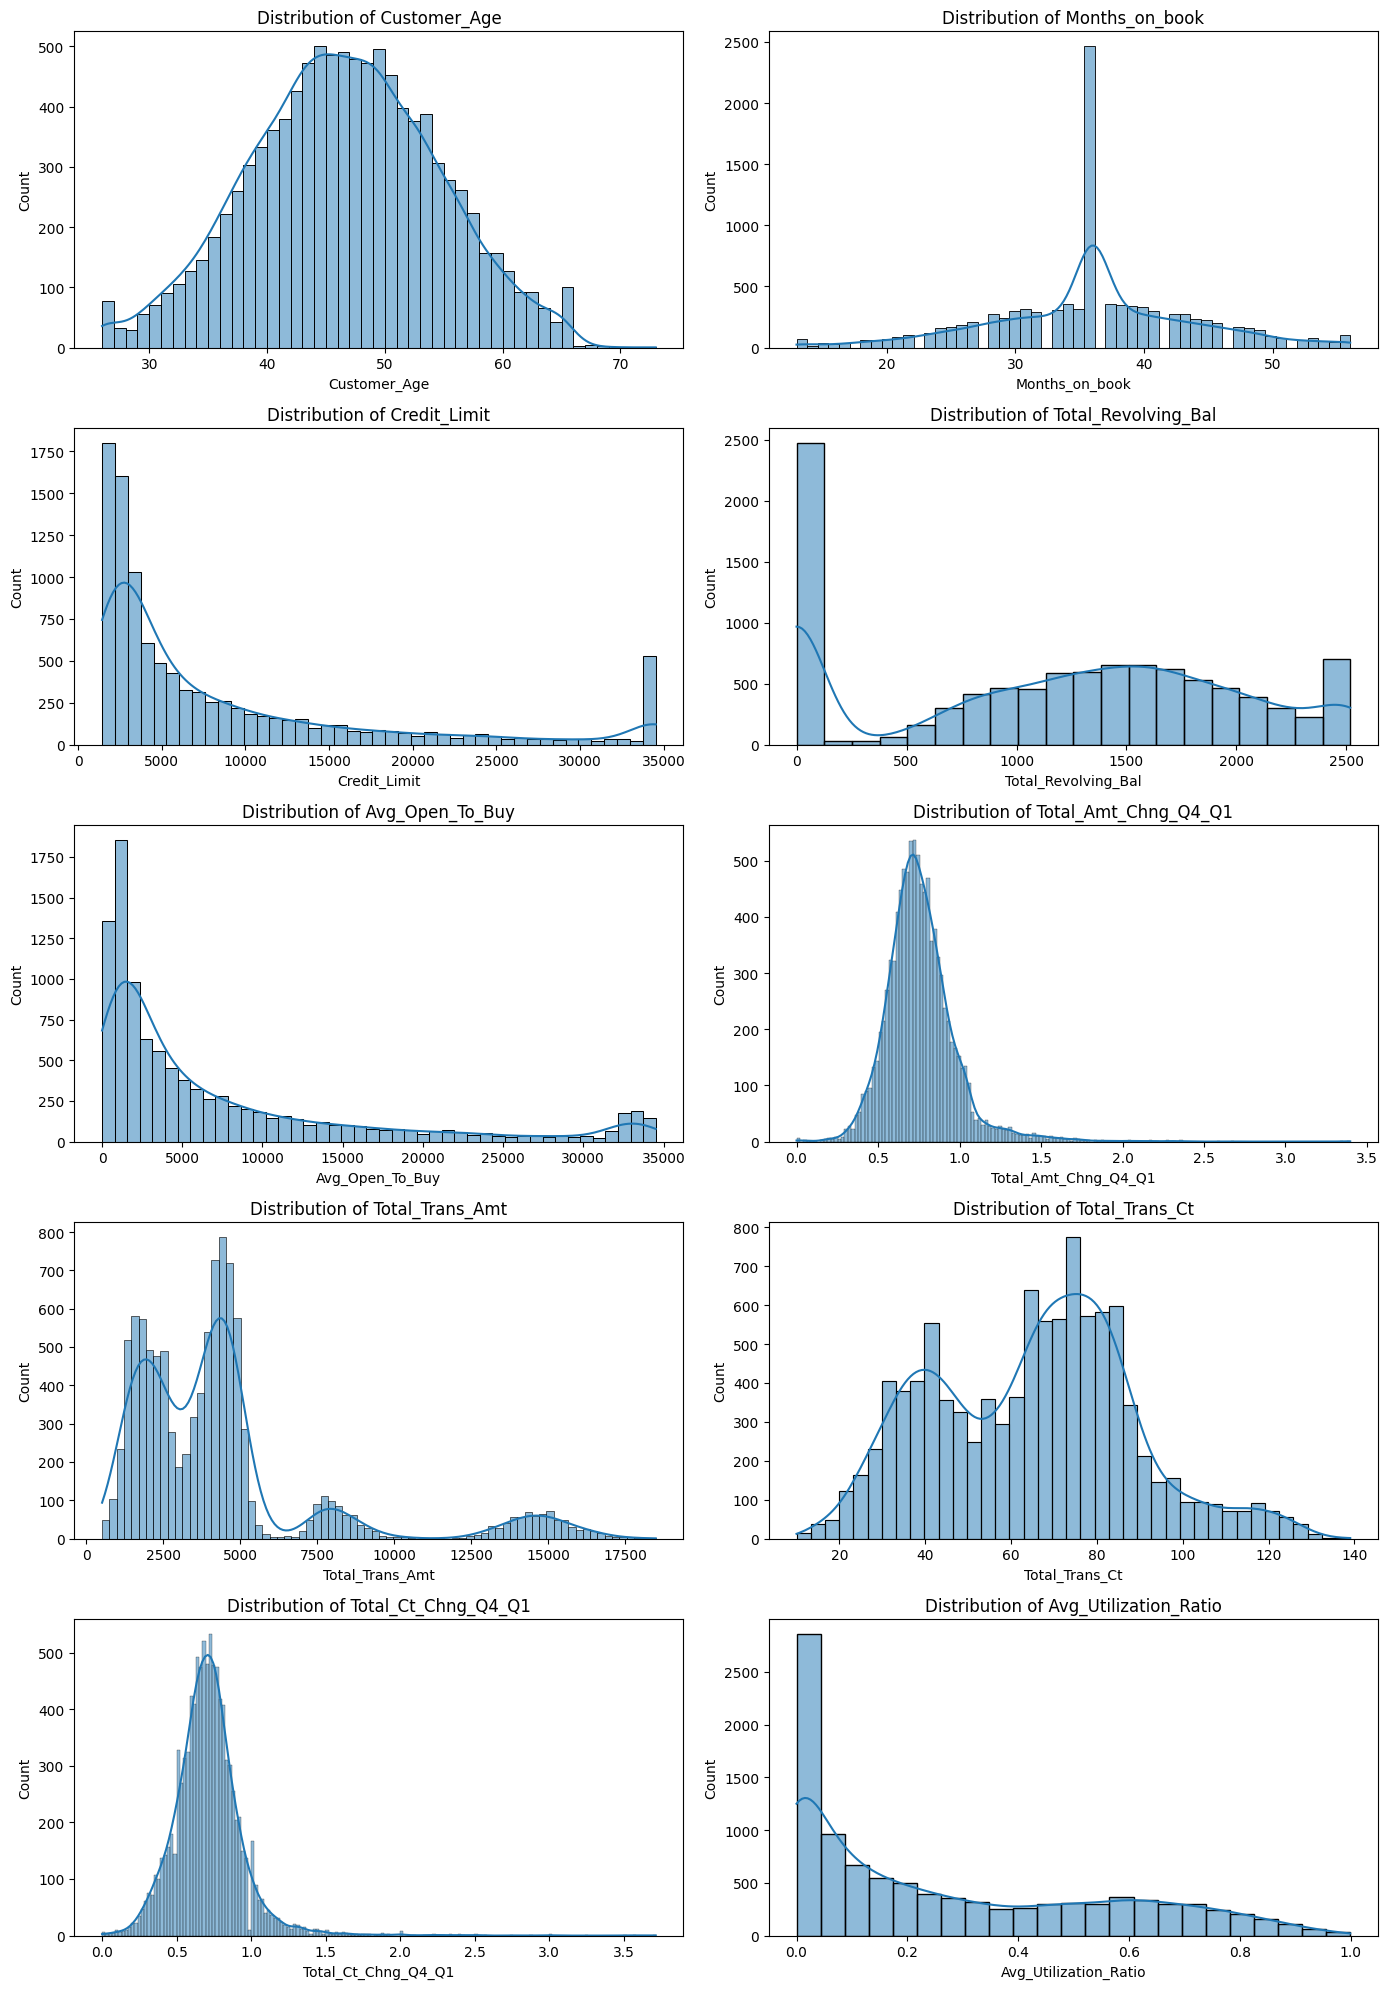

In [19]:
n = len(continuous_cols)
rows = int(np.ceil(n / 2))

fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* 이진형 타겟에서 수치형과의 관계 그래프를 어떻게 해야할지 고민을 좀.. 로지스틱 곡선을 그렸는데 너무 극단적으로 나온다..

> 수치형 변수 간 상관관계 확인 (다중공선성 파악)

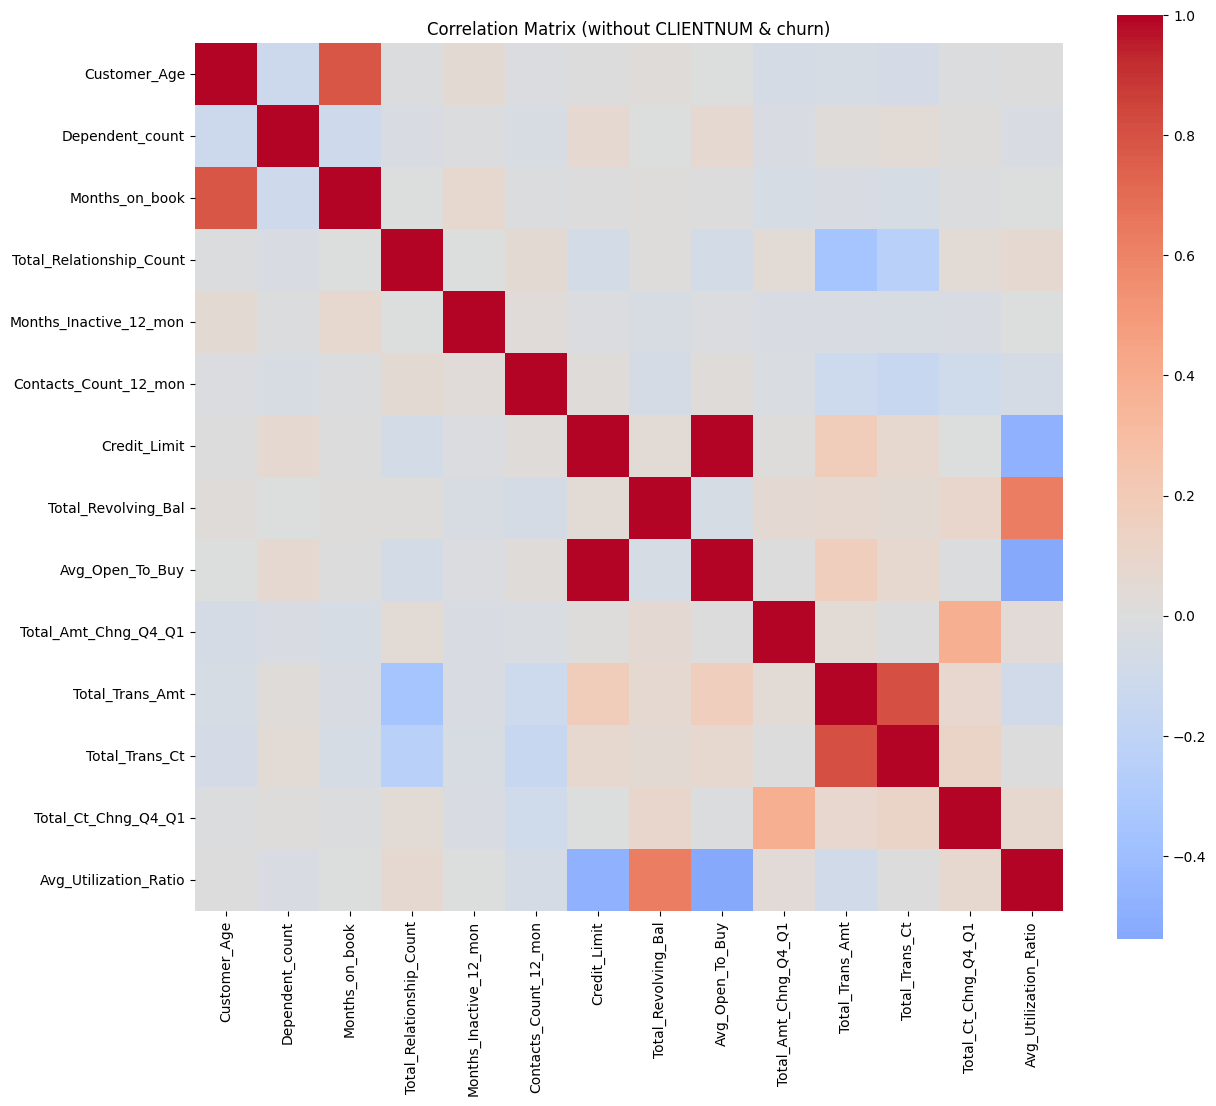

In [37]:
corr_df = df.drop(columns=['CLIENTNUM', 'churn'])

# 수치형만 (혹시 모르니 안전하게)
corr_df = corr_df.select_dtypes(include=np.number)

corr = corr_df.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            square=True)

plt.title("Correlation Matrix (without CLIENTNUM & churn)")
plt.show()

* 상관관계 높게 나타난 3개 pair는 파생된 변수이거나, 비슷한 변수.
(Credit_Limit ↔ Avg_Open_To_Buy, Total_Trans_Amt ↔ Total_Trans_Ct, Total_Amt_Chng_Q4_Q1 ↔ Total_Ct_Chng_Q4_Q1)

* 음의 상관관계 나타난 pair는 변수의 수학적 관계에 의해 나타나는 당연한 관계이다.
(Credit_Limit ↔ Avg_Utilization_Ratio, Avg_Open_To_Buy ↔ Avg_Utilization_Ratio)

* 추후 모델링 시 다중공선성 방지를 위해 위의 변수들은 필요에 따라 선택하거나 일부 제거해야 한다.

> 이후 진행 방향
* 표본 수에 유의해서 유의미한 변수들을 조합, 이를 기반으로 고객 classification 진행. 
* 중요도가 높으면서 유의하게 나타나는 변수를 일부 선택해서 심층적인 추가 분석 진행.
* 카드 데이터에 대한 배경 지식 학습.. 다른 분석 결과들 보면서 대체로 나타나는 공통적인 결과를 파악하고, 내가 다루는 데이터에서 그와는 차별적으로 나타나는 것을 볼 수 있어야 할 듯